In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


/tmp/ipykernel_1806087/1328765081.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1806087/1328765081.py:99: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


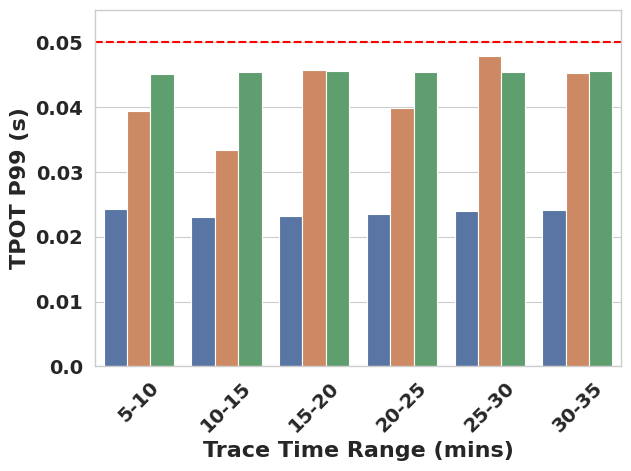

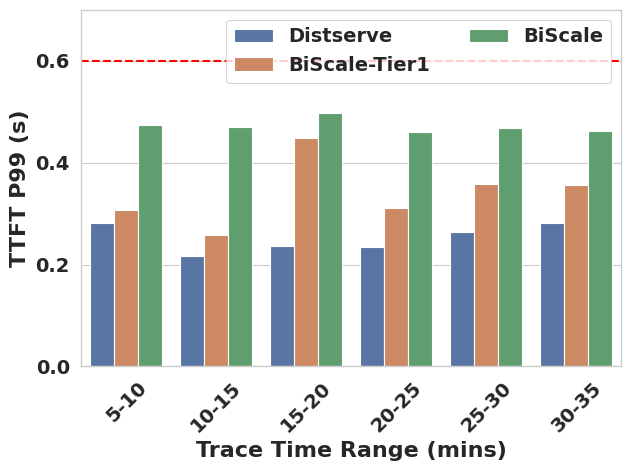

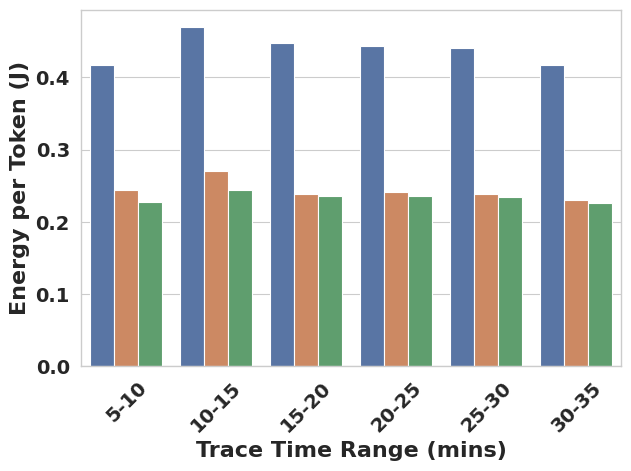

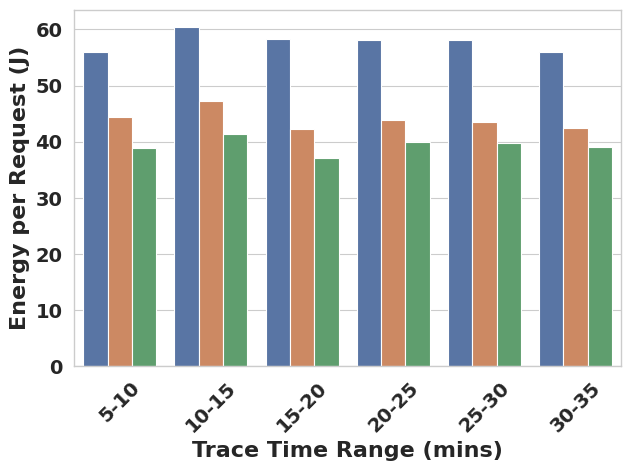

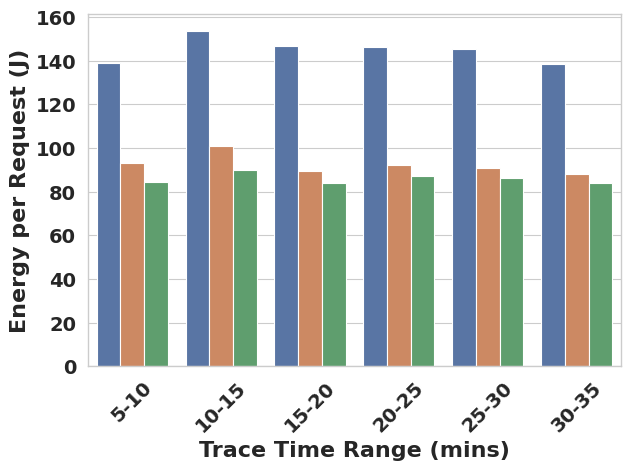

In [2]:
path_disag = "/export2/obasit/ClusterLevelServing/logs_asplos_tighter_tbt/profiler_logs_1_Aug17/disag/metrics.csv"
df_results_disag = pd.read_csv(path_disag)

path_coll = "/export2/obasit/ClusterLevelServing/logs_asplos_tighter_tbt/profiler_logs_1_Aug18/chunked/metrics.csv"
df_results_coll = pd.read_csv(path_coll)

df_results = pd.concat([df_results_disag, df_results_coll], ignore_index=True)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_6': 'Distserve 85',
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_5': 'Distserve 70',
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_4': 'Distserve 55',
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_3': 'Distserve 40',
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_2': 'Distserve 25',
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_1': 'Distserve 10',
    'OURS_AUG16_AZURE_SHAREGPT_P67_6': 'BiScale-Tier1 85',
    'OURS_AUG16_AZURE_SHAREGPT_P67_5': 'BiScale-Tier1 70',
    'OURS_AUG16_AZURE_SHAREGPT_P67_4': 'BiScale-Tier1 55',
    'OURS_AUG16_AZURE_SHAREGPT_P67_3': 'BiScale-Tier1 40',
    'OURS_AUG16_AZURE_SHAREGPT_P67_2': 'BiScale-Tier1 25',
    'OURS_AUG16_AZURE_SHAREGPT_P67_1': 'BiScale-Tier1 10',
    'OURS_AUG16_AZURE_SHAREGPT_P67_6_DVFS': 'BiScale 85',
    'OURS_AUG16_AZURE_SHAREGPT_P67_5_DVFS': 'BiScale 70',
    'OURS_AUG16_AZURE_SHAREGPT_P67_4_DVFS': 'BiScale 55',
    'OURS_AUG16_AZURE_SHAREGPT_P67_3_DVFS': 'BiScale 40',
    'OURS_AUG16_AZURE_SHAREGPT_P67_2_DVFS': 'BiScale 25',
    'OURS_AUG16_AZURE_SHAREGPT_P67_1_DVFS': 'BiScale 10',
}


# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)
df_results = df_results[df_results['expr_dir'].isin(rename_mapping.values())]
df_results = df_results[df_results["expr_dir"].isin(set(rename_mapping.values()))].copy()

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale'], ordered=True)
# df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale', 'Collocated-Tier1', 'Collocated'], ordered=True)

df_results = df_results.sort_values(['rps', 'name'])

####################### TPOT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TPOT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.055)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.01, 0.02, 0.03, 0.04, 0.05])
ax.set_yticklabels(['0.0', '0.01', '0.02', '0.03', '0.04', '0.05'], fontsize=14, fontweight='bold')
ax.legend_.remove()

plt.tight_layout()
plt.savefig("figs/real_67p_trace_tpot.pdf", format="pdf")

######################## TTFT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TTFT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.7)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14, fontweight='bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})

plt.tight_layout()
plt.savefig("figs/real_67p_trace_ttft.pdf", format="pdf")

############################ energy per token - decode #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="decode_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Token (J)', fontsize=16, fontweight='bold')

ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_67p_trace_energy_per_token_decode.pdf", format="pdf")

############################ energy per request - prefill #######################
df_results_dis = df_results[df_results["name"].isin(["Distserve", "BiScale-Tier1", "BiScale"])].copy()
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="prefill_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')

ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_67p_trace_energy_per_request_prefill.pdf", format="pdf")

############################ energy per request - total #######################

df_results['energy_per_req'] = df_results['energy_j'] / df_results['num_requests']
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_req", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')

ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_67p_trace_energy_per_request_total.pdf", format="pdf")

In [5]:
# Normalize energy with Distserve energy for both prefill and decode
df_results['energy_norm_prefi_D'] = df_results.apply(
    lambda row: (1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['prefill_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_deco_D'] = df_results.apply(
    lambda row: (1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['decode_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_prefi_M'] = df_results.apply(
    lambda row: (1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'BiScale-Tier1')
    ]['prefill_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_deco_M'] = df_results.apply(
    lambda row: (1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'BiScale-Tier1')
    ]['decode_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_D'] = df_results.apply(
    lambda row: (1 - row['energy_per_req'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['energy_per_req'].values[0]) * 100,
    axis=1
)

df_results[['expr_dir', 'energy_per_token', 'energy_norm_prefi_D', 'energy_norm_deco_D', 'energy_norm_prefi_M', 'energy_norm_deco_M', 'energy_norm_D']].sort_values('expr_dir', ascending=False)

,expr_dir,energy_per_token,energy_norm_prefi_D,energy_norm_deco_D,energy_norm_prefi_M,energy_norm_deco_M,energy_norm_D
63,Distserve 85,0.695279,0.000000,0.000000,-31.674254,-80.675601,0.000000
57,Distserve 70,0.729569,0.000000,0.000000,-33.139470,-84.528119,0.000000
51,Distserve 55,0.730392,0.000000,0.000000,-32.006836,-82.984380,0.000000
45,Distserve 40,0.737867,0.000000,0.000000,-37.706555,-87.558620,0.000000
39,Distserve 25,0.771084,0.000000,0.000000,-28.033726,-73.622313,0.000000
33,Distserve 10,0.693944,0.000000,0.000000,-25.728466,-71.103539,0.000000
275,BiScale-Tier1 85,0.444069,24.055009,44.652184,0.000000,0.000000,36.591390
263,BiScale-Tier1 70,0.456264,24.890793,45.807717,0.000000,0.000000,37.481083
251,BiScale-Tier1 55,0.460198,24.246347,45.350527,0.000000,0.000000,36.975800
239,BiScale-Tier1 40,0.449656,27.381815,46.683336,0.000000,0.000000,38.980542



P99 Power (W) by System:
name
BiScale          7098.53816
BiScale-Tier1    6609.27415
Distserve        9869.07984
Name: power_w, dtype: float64


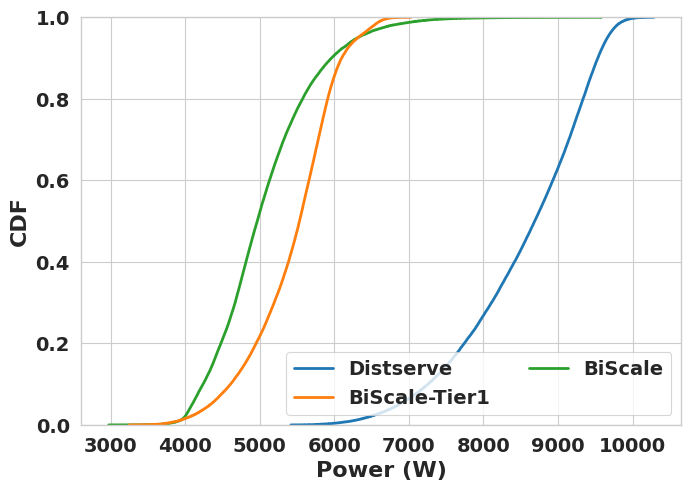

In [6]:
############################ power cdf #######################

from pathlib import Path
import numpy as np
from matplotlib.lines import Line2D

path_disag = "/export2/obasit/ClusterLevelServing/logs_asplos_tighter_tbt/profiler_logs_1_Aug17/disag/metrics.csv"
df_results_disag = pd.read_csv(path_disag)

path_coll = "/export2/obasit/ClusterLevelServing/logs_asplos_tighter_tbt/profiler_logs_1_Aug18/chunked/metrics.csv"

power_source_specs = [
    (
        Path("/export2/obasit/ClusterLevelServing/logs_asplos_tighter_tbt/profiler_logs_1_Aug17/disag"),
        df_results_disag,
    ),
]

def load_run_power_series(run_root: Path) -> pd.DataFrame:
    total_power_path = run_root / "total_power.csv"
    if total_power_path.exists():
        power_df = pd.read_csv(total_power_path)
        if not power_df.empty and "power_w" in power_df.columns:
            return power_df[["power_w"]].copy()
        return pd.DataFrame(columns=["power_w"])

    power_log_path = run_root / "power_log.csv"
    if not power_log_path.exists():
        return pd.DataFrame(columns=["power_w"])

    raw_power_df = pd.read_csv(power_log_path)
    power_cols = [
        col for col in raw_power_df.columns
        if col.startswith("GPU_") and col.endswith("_power_w")
    ]
    if not power_cols:
        return pd.DataFrame(columns=["power_w"])

    power_df = raw_power_df[power_cols].sum(axis=1).to_frame(name="power_w")
    return power_df

power_rows = []
for root_dir, metrics_df in power_source_specs:
    source_df = metrics_df[metrics_df["instance"] == "total"].copy()
    source_df["run_dir_name"] = source_df["expr_dir"]
    source_df["expr_dir"] = source_df["expr_dir"].replace(rename_mapping)
    source_df = source_df[source_df["expr_dir"].isin(rename_mapping.values())]
    source_df = source_df[~source_df["expr_dir"].str.contains("OURS_R5_JAN3_OLD_P90_.*_DVFS", regex=True)]
    source_df["name"] = source_df["expr_dir"].str.replace(r"\s+\d+$", "", regex=True)
    source_df["name"] = pd.Categorical(
        source_df["name"],
        categories=["Distserve", "BiScale-Tier1", "BiScale"],
        ordered=True,
    )

    for _, row in source_df.iterrows():
        power_df = load_run_power_series(root_dir / row["run_dir_name"])
        if power_df.empty:
            continue
        power_df = power_df[["power_w"]].copy()
        power_df["name"] = row["name"]
        power_rows.append(power_df)

power_cdf_df = pd.concat(power_rows, ignore_index=True)
power_cdf_df = power_cdf_df.dropna(subset=["power_w", "name"])

palette = {
    "Distserve": "#1f77b4",
    "BiScale-Tier1": "#ff7f0e",
    "BiScale": "#2ca02c",
}

sns.set_theme(context="paper", style="whitegrid")
plt.figure(figsize=(7, 5))
ax = sns.ecdfplot(
    data=power_cdf_df,
    x="power_w",
    hue="name",
    hue_order=["Distserve", "BiScale-Tier1", "BiScale"],
    palette=palette,
    linewidth=2,
)

ax.set_xlabel("Power (W)", fontsize=16, fontweight="bold")
ax.set_ylabel("CDF", fontsize=16, fontweight="bold")
ax.tick_params(axis="both", labelsize=14)
for label in ax.get_xticklabels():
    label.set_fontweight("bold")
for label in ax.get_yticklabels():
    label.set_fontweight("bold")
legend_handles = [
    Line2D([0], [0], color=palette[name], lw=2, label=name)
    for name in ["Distserve", "BiScale-Tier1", "BiScale"]
]
ax.legend(handles=legend_handles, title="", ncol=2, prop={"size": 14, "weight": "bold"})
plt.tight_layout()
plt.savefig("figs/real_67p_trace_power_cdf.pdf", format="pdf")

print("\nP99 Power (W) by System:")
print(power_cdf_df.groupby("name")["power_w"].quantile(0.99))
